In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
from astropy.io import fits
from matplotlib import colors
import matplotlib.patches as patches
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
from ellipse import LsqEllipse

In [2]:
import pickle

alma_image = pickle.load(open('alma_image', 'rb'))
alma_image_d = pickle.load(open('alma_image_d', 'rb'))

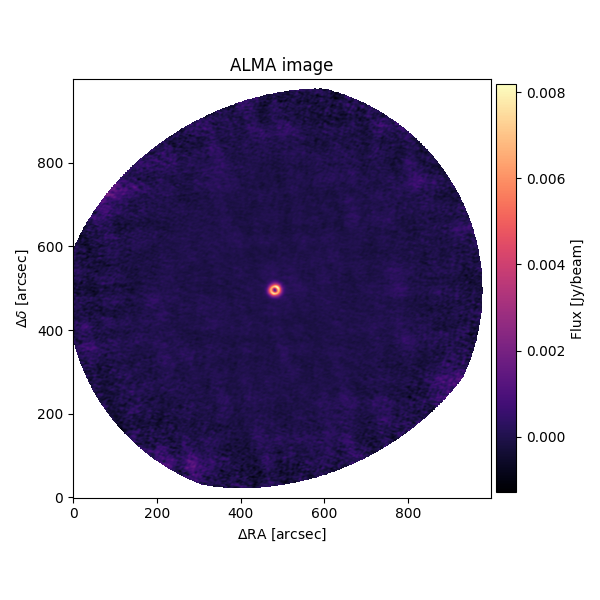

In [3]:
scale = 0.028  # arcsec/px

alma_d_extent = [
    -alma_image.shape[1] * scale / 2 + 0.504,  # Left = -width/2 (as)
    alma_image.shape[1] * scale / 2 + 0.504,   # Right = +width/2 (as)
    -alma_image.shape[0] * scale / 2 + 0.112,  # Bottom = -height/2 (as)
    alma_image.shape[0] * scale / 2 + 0.112,   # Top = +height/2 (as)
]

plt.figure(figsize=(6,6))
plt.title('ALMA image')
plt.imshow(alma_image_d, origin='lower', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.01, label=r"Flux [Jy/beam]")
plt.xlabel(r'$\Delta$RA [arcsec]')
plt.ylabel(r'$\Delta\delta$ [arcsec]')
#plt.xlim(-1.0, 1.0)
#plt.ylim(-1.0, 1.0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2570/1786868674.py:23: RuntimeWarning: Mean of empty slice.
  profile = [alma_image_d[(r >= i) & (r < i+1) & wedge_mask].mean() for i in radii]
/home/enricogrippi/anaconda3/envs/astrolab2/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/enricogrippi/anaconda3/envs/astrolab2/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/enricogrippi/anaconda3/envs/astrolab2/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/enricogrippi/anaconda3/envs/astrolab2/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


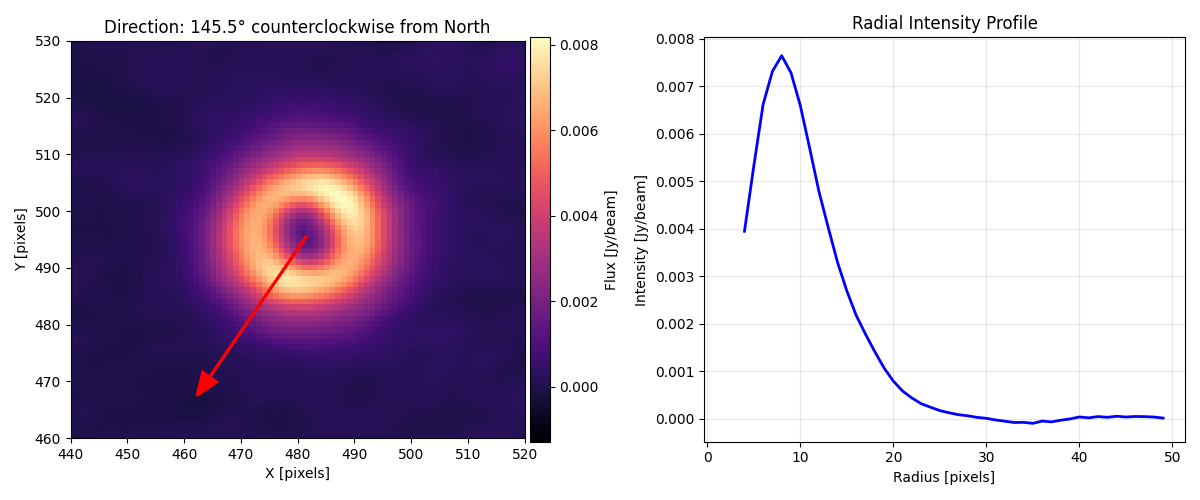

[nan, nan, 0.002521719571603336, nan, 0.003944115467857257, 0.005315664182436128, 0.006610981974176803, 0.007309477719359821, 0.007639635758918451, 0.007280057783645834, 0.006591785294165821, 0.0056993617557686395, 0.004783398585409899, 0.004025566542951782, 0.003291273596643199, 0.0026902429371878783, 0.0021770695767418524, 0.001780949049169282, 0.0014117619781831322, 0.0010679319730308254, 0.0007895757959698473, 0.0005802845057919778, 0.0004330199780182082, 0.00031434159327357186, 0.00023942843541116494, 0.00016887300693886967, 0.00012245148737385328, 8.25379978596441e-05, 5.925789535408223e-05, 2.641756126597818e-05, 6.349584607653491e-06, -2.8852679866540822e-05, -5.492727447525369e-05, -8.19179243181313e-05, -7.868300488914874e-05, -9.937848304010342e-05, -5.178617722441804e-05, -6.866505865054051e-05, -3.363457226656163e-05, -6.515546439061382e-06, 3.518361659105386e-05, 1.6349126966859768e-05, 4.351059240007156e-05, 2.7674464786636024e-05, 4.944347306217239e-05, 3.36420754664410

In [4]:
# Settings
center_x = 481.5
center_y = 495.5
angle_deg = 145.5  # degrees COUNTERCLOCKWISE from North (+y axis)

def radial_profile(x_center, y_center, angle_deg, pixel_coverage):
    # Calculate coordinates
    y, x = np.indices(alma_image_d.shape)
    dx, dy = x - center_x, y - center_y
    
    # Calculate angles (0° = North = +y, 90° = West = -x for counterclockwise)
    angles = np.arctan2(-dx, dy) * 180/np.pi  # Note: -dx for counterclockwise
    angles = (angles + 360) % 360  # Ensure positive angles
    
    # Calculate distances
    r = np.sqrt(dx**2 + dy**2)
    
    # Create wedge mask (±5 degrees around target angle)
    wedge_mask = (angles > angle_deg - 10) & (angles < angle_deg + 10)
    
    # Calculate radial profile
    radii = np.arange(pixel_coverage)
    profile = [alma_image_d[(r >= i) & (r < i+1) & wedge_mask].mean() for i in radii]
    profile_errors = [alma_image_d[(r >= i) & (r < i+1) & wedge_mask].std() for i in radii]

    return radii, profile, profile_errors

radii, profile, profile_errors = radial_profile(center_x, center_y, angle_deg, 50)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: ALMA image with arrow
im = ax1.imshow(alma_image_d, origin='lower', cmap='magma')
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.01, label='Flux [Jy/beam]')

# Draw arrow for COUNTERCLOCKWISE direction from North
arrow_length = 30
angle_rad = np.radians(-angle_deg)  # Negative for counterclockwise
end_x = center_x + arrow_length * np.sin(angle_rad)
end_y = center_y + arrow_length * np.cos(angle_rad)

ax1.arrow(center_x, center_y, end_x - center_x, end_y - center_y, 
          head_width=3, head_length=4, fc='red', ec='red', linewidth=2)

ax1.set_xlabel('X [pixels]')
ax1.set_ylabel('Y [pixels]')
ax1.set_title(f'Direction: {angle_deg}° counterclockwise from North')
ax1.set_xlim(440, 520)
ax1.set_ylim(460, 530)

# Plot 2: Radial profile
ax2.plot(radii, profile, 'b-', linewidth=2)
ax2.set_xlabel('Radius [pixels]')
ax2.set_ylabel('Intensity [Jy/beam]')
ax2.set_title('Radial Intensity Profile')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print (profile)

In [5]:
from scipy.optimize import curve_fit

def gaussian(x, amplitude, mean, stddev):
    """Gaussian function for fitting."""
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2))

[       nan        nan 0.                nan 0.         0.04077107
 0.         0.02863683 0.0094214  0.02025726 0.03419741 0.03105596
 0.03739316 0.01867308 0.0338619  0.02080831 0.01520597 0.0154647
 0.00838644 0.01309021 0.00854586 0.00696327 0.00662946 0.00657018
 0.00608721 0.00403476 0.00265775 0.00235686 0.00248868 0.00313547
 0.00250266 0.00231841 0.00399197 0.00591911 0.0081668  0.00895956
 0.01138454 0.01104428 0.01051259 0.01188504 0.01063347 0.01153253
 0.00884826 0.00839449 0.00545307 0.00557797 0.00439485 0.00389342
 0.00452764 0.00585332]


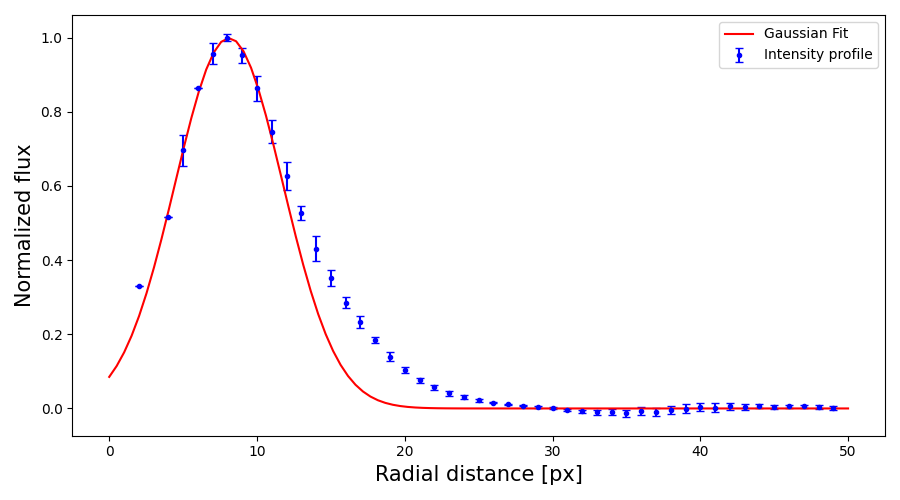

In [6]:
rms = 1.12e-04

# Fit Gaussian while excluding peaks
height_threshold = 0.03  # Adjust based on your data

norm_flux = profile / np.nanmax(profile)
norm_error_flux = (profile_errors / np.nanmax(profile))

print (norm_error_flux)

# Selecting only the luminosity peak that interests us:
mask = (radii >= 4) & (radii <= 11)
radii_masked = radii[mask]
norm_flux_masked = norm_flux[mask]
popt, pcov = curve_fit(gaussian, radii_masked, norm_flux_masked)

radii_fit = np.linspace(0, 50, 100)

# Reconstruct the fitted Gaussian
norm_flux_fit = gaussian(radii_fit, *popt)

# Plot results
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(radii, norm_flux, yerr=norm_error_flux, fmt='bo', markersize=3, capsize=3, label="Intensity profile")
ax.plot(radii_fit, norm_flux_fit, 'r-', label="Gaussian Fit")
ax.set_ylabel('Normalized flux', fontsize=15)
ax.set_xlabel('Radial distance [px]', fontsize=15)
ax.legend()

plt.tight_layout()
plt.show()

In [7]:
AU_scale = 4.23

perr = np.sqrt(np.diag(pcov))

print ('fitted parameters:', popt)
print ('errors on the fitted parameters:', perr)
print ('peak value (AU):', f'{popt[1]*AU_scale: .1f} \u00B1 {perr[1]*AU_scale: .1f}')
print ('radial width of the blob (AU):', f'{2*popt[2]*AU_scale: .1f} \u00B1 {2*perr[2]*AU_scale: .1f}')

fitted parameters: [0.99885724 8.10398981 3.65125523]
errors on the fitted parameters: [0.00902962 0.0491395  0.08087083]
peak value (AU):  34.3 ±  0.2
radial width of the blob (AU):  30.9 ±  0.7
